In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
# Install all packages from
!pip install -r ../../requirements.txt

In [4]:
import json, os, csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# !!!global!!!
plt.style.use('default')
# plt.style.use('dark_background')

Download stats analysis:

In [6]:
# Load stats/download_stats.csv and do analysis

df = pd.read_csv("../../stats/download_stats.csv")
df.head()

,recid,file,bytes,start,end,duration_s,rate_Bps,success,error,expected_size,expected_checksum,computed_checksum_numeric,checksum_ok,attempts


In [7]:
# Ensure CSV header includes the new 'attempts' column to avoid tokenizing errors

csv_path = "../../stats/download_stats.csv"
expected_columns = ['recid','file','bytes','start','end','duration_s','rate_Bps',
                    'success','error','expected_size','expected_checksum',
                    'computed_checksum_numeric','checksum_ok','attempts']

if os.path.exists(csv_path):
    try:
        with open(csv_path, 'r', newline='', encoding='utf-8') as f:
            reader = csv.reader(f)
            header = next(reader, [])
    except Exception:
        header = []

    # If header differs from expected, rewrite only the header line to the expected columns.
    # This preserves existing data rows while making future reads/appends consistent.
    if header != expected_columns:
        with open(csv_path, 'r', encoding='utf-8') as f:
            lines = f.read().splitlines()
        if lines:
            lines[0] = ','.join(expected_columns)
        else:
            lines = [','.join(expected_columns)]
        outpath = csv_path.split('.')[0] + '_updated.csv'
        with open(outpath, 'w', encoding='utf-8', newline='') as f:
            f.write('\n'.join(lines) + '\n')

In [8]:
# print all column names
print(df.columns)

Index(['recid', 'file', 'bytes', 'start', 'end', 'duration_s', 'rate_Bps',
       'success', 'error', 'expected_size', 'expected_checksum',
       'computed_checksum_numeric', 'checksum_ok', 'attempts'],
      dtype='str')


In [9]:
# total size of data in num of unique recids, Gb, average speed, total data, total time spent downloading, errors, etc.

# Index(['recid', 'file', 'bytes', 'start', 'end', 'duration_s', 'rate_Bps',
#       'success', 'error', 'expected_size', 'expected_checksum',
#       'computed_checksum_numeric', 'checksum_ok'],
#      dtype='object')

total_errors = df['success'].value_counts().get(False, 0)
df = df[df['success'] == True]  # Filter to only successful data for accurate stats
recids = df['recid'].nunique()
total_size = df['bytes'].sum()
average_download_speed = df['rate_Bps'].mean()
average_speed = total_size / (df['end'].max() - df['start'].min())
total_downloads = len(df)
total_time_spent = df['duration_s'].sum()

print(f"Downloaded unique recids: {recids}")
print(f"Total size of downloads: {total_size / (1024**3)} GB")
print(f"Average download speed: {average_download_speed / (1024**2)} MBps")
print(f"Average speed (total size / total time): {average_speed / (1024**2)} MBps")
print(f"Total downloads: {total_downloads}")
print(f"Total time spent downloading: {total_time_spent} seconds")
print(f"Total errors: {total_errors}")

Downloaded unique recids: 0
Total size of downloads: 0.0 GB
Average download speed: nan MBps
Average speed (total size / total time): nan MBps
Total downloads: 0
Total time spent downloading: 0 seconds
Total errors: 0


/tmp/ipykernel_3023/3862941726.py:7: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.savefig('../../figs/download_size_distribution.png', bbox_inches='tight')


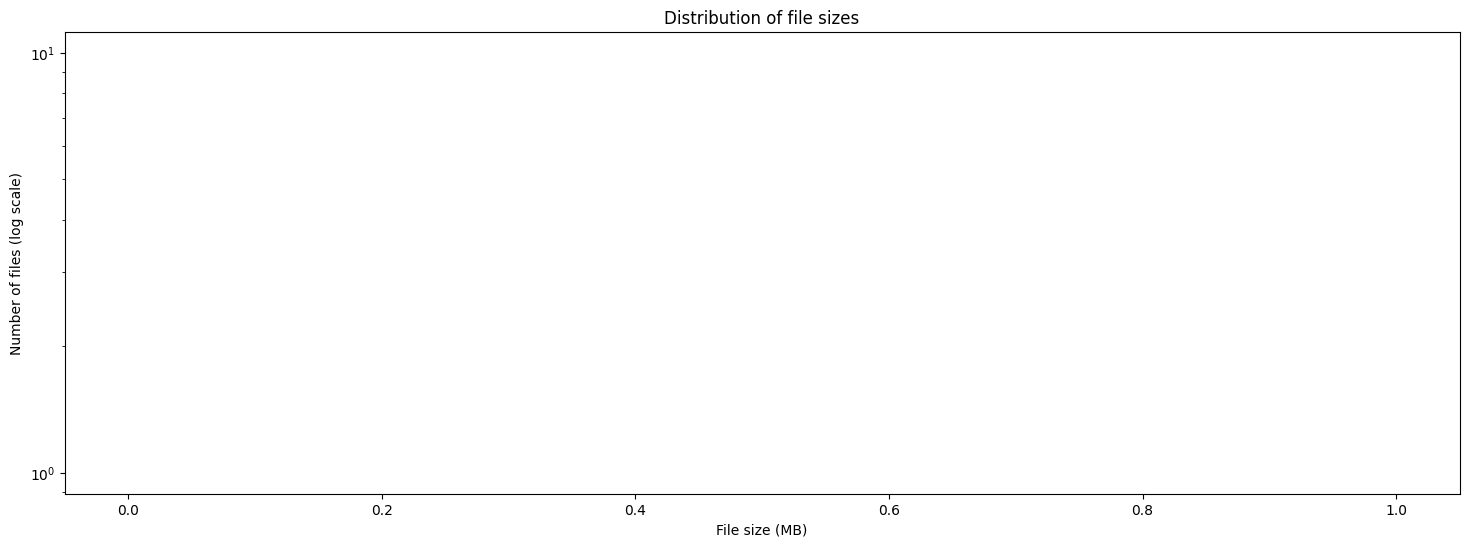

In [11]:
# Plot histogram of download sizes, x logarithmic, in MB, with 50 bins, label axes, title, etc.
plt.figure(figsize=(18, 6))
plt.hist(df['bytes'] / (1024**2), bins=50, log=True)
plt.xlabel('File size (MB)')
plt.ylabel('Number of files (log scale)')
plt.title('Distribution of file sizes')
plt.savefig('../../figs/download_size_distribution.png', bbox_inches='tight')
plt.show()

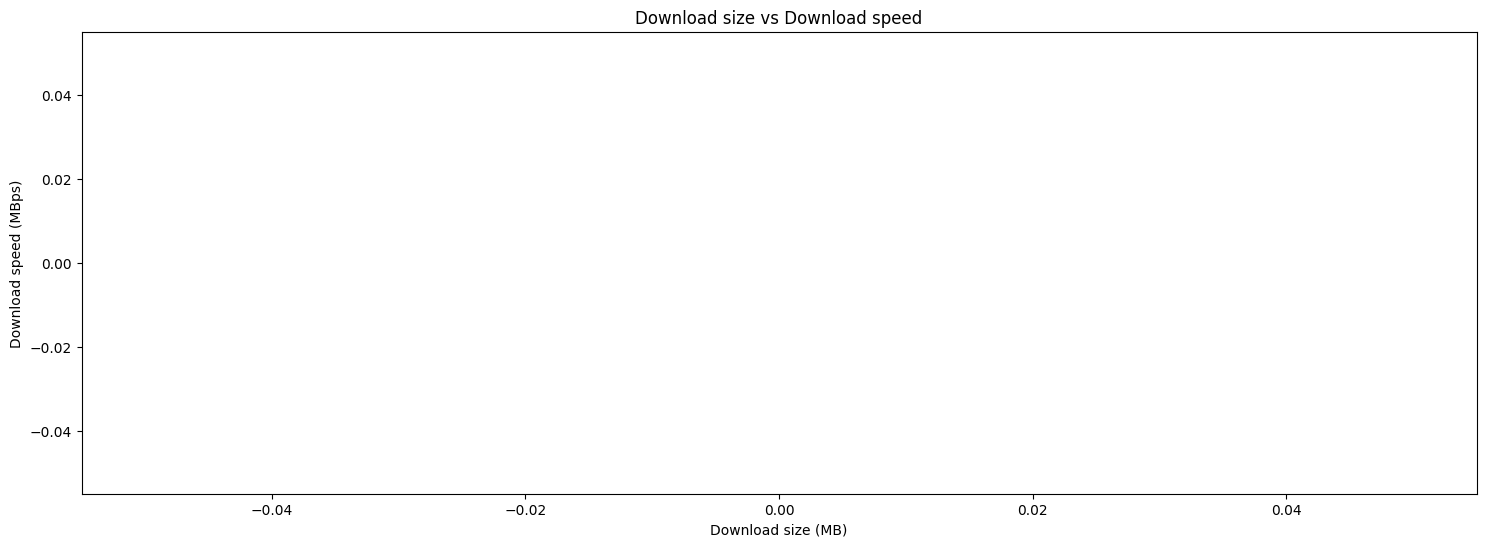

In [12]:
# Correlation between download size and download speed
plt.figure(figsize=(18, 6))
plt.scatter(df['bytes'] / (1024**2), df['rate_Bps'] / (1024**2), alpha=0.01)
plt.xlabel('Download size (MB)')
plt.ylabel('Download speed (MBps)')
plt.title('Download size vs Download speed')
plt.savefig('../../figs/download_size_vs_speed.png', bbox_inches='tight')
plt.show()

In [13]:
# print ordered bins of 50 from distribution of number of files per recid, skip empty bins
files_per_recid = df['recid'].value_counts()

print(files_per_recid.max())

bins = pd.cut(files_per_recid, bins=range(0, files_per_recid.max() + 50, 20))
binned_counts = files_per_recid.groupby(bins).size()
binned_countsf = binned_counts[binned_counts.values != 0]
print(binned_countsf)

nan


TypeError: 'float' object cannot be interpreted as an integer

In [14]:
# plot the bins on a log scale, wide graph, modify tics - print every tenth label
plt.figure(figsize=(18, 6))
plt.bar(binned_counts.index.astype(str), binned_counts.values)
plt.yscale('log')
plt.xlabel('Number of files per recid (binned)')
plt.ylabel('Number of recids (log scale)')
plt.title('Distribution of number of files per recid')
plt.xticks(rotation=45)
plt.gca().set_xticks(plt.gca().get_xticks()[::10])
plt.savefig('../figs/files_per_recid_distribution.png', bbox_inches='tight')
plt.show()

NameError: name 'binned_counts' is not defined

<Figure size 1800x600 with 0 Axes>

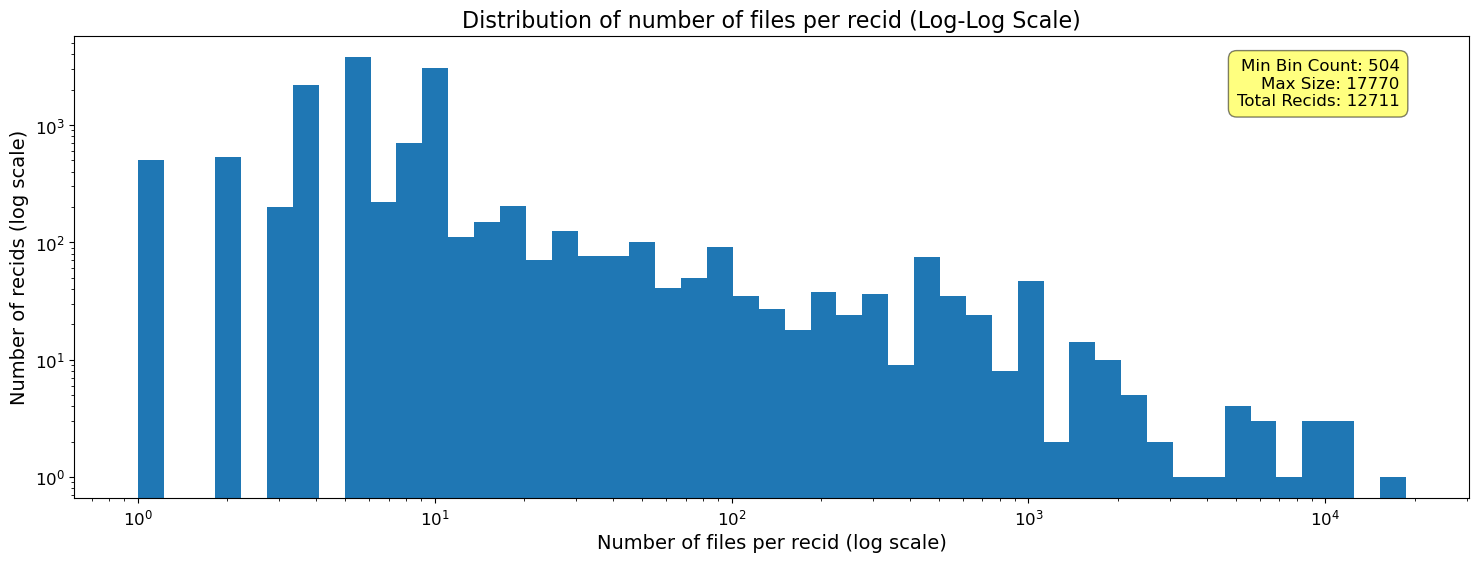

In [ ]:
# plot the distribution of number of files per recid with logarithmic x-axis
plt.figure(figsize=(18, 6))

# Calculate logarithmic bins for the histogram
min_val = files_per_recid.min()
max_val = files_per_recid.max()
# Ensure min_val is at least 1 for log10, as counts cannot be 0
if min_val == 0:
    min_val = 1
# Create 50 logarithmically spaced bins, extending slightly beyond the max value
log_bins = np.logspace(np.log10(min_val), np.log10(max_val * 1.05), num=50)

# Plot the histogram with logarithmic x and y scales
n, bins, patches = plt.hist(files_per_recid.values, bins=log_bins, log=True)

plt.xscale('log') # Set x-axis to logarithmic scale
plt.yscale('log') # Keep y-axis to logarithmic scale

plt.xlabel('Number of files per recid (log scale)', fontsize=14)
plt.ylabel('Number of recids (log scale)', fontsize=14) # y-axis represents the count of recids within each file count bin
plt.title('Distribution of number of files per recid (Log-Log Scale)', fontsize=16)

# Increase font size for tick values
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)

# Add a text box with min bin value, max bin value, and total sum of bins
min_bin_value = n[0] if len(n) > 0 else 0
max_bin_value = n[-1] if len(n) > 0 else 0
total_recids_in_hist = int(n.sum())

text_str = f"Min Bin Count: {int(min_bin_value)}\n" \
           f"Max Size: {int(max_val)}\n" \
           f"Total Recids: {int(total_recids_in_hist)}"

plt.text(0.95, 0.95, text_str, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# When using plt.xscale('log') with plt.hist, matplotlib typically handles ticks well automatically.
# Manual xtick adjustments are usually not needed and can interfere with the logarithmic scaling.

plt.savefig('../../figs/files_per_recid_log_distribution.png', bbox_inches='tight')
plt.show()

<Figure size 1800x600 with 0 Axes>

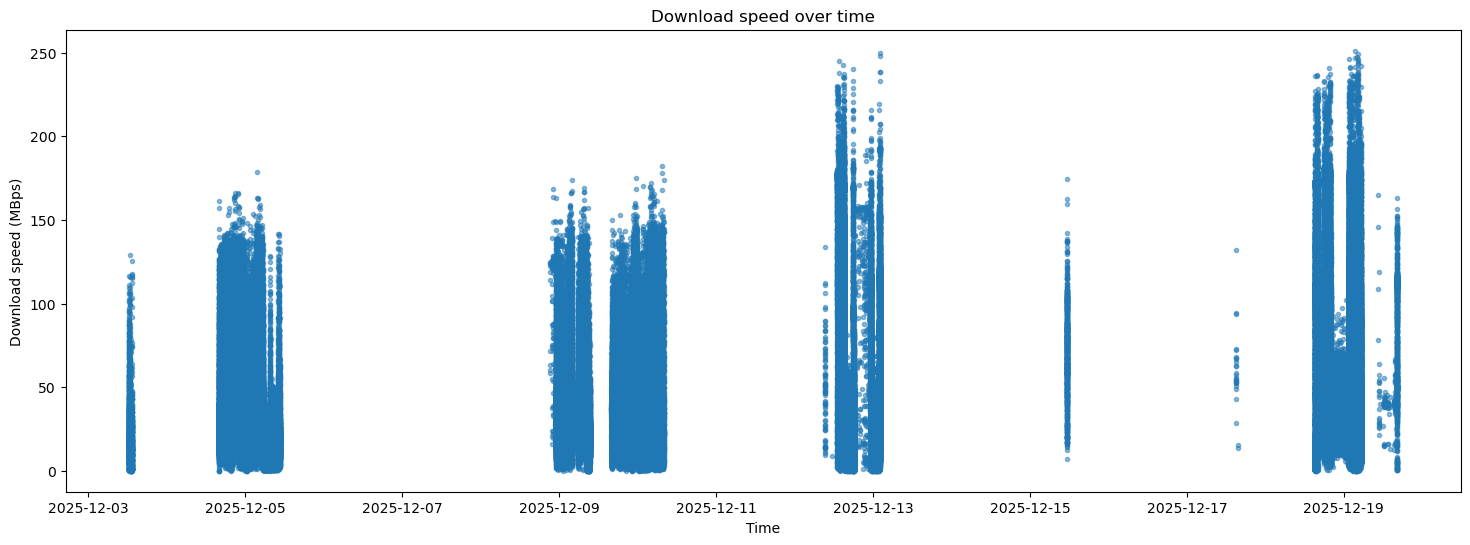

In [15]:
# plot download speed over time
plt.figure(figsize=(18, 6))
df['start_time'] = pd.to_datetime(df['start'], unit='s')
df = df.sort_values(by='start_time')
plt.figure(figsize=(18, 6))
plt.plot(df['start_time'], df['rate_Bps'] / (1024**2), marker='.', linestyle='None', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Download speed (MBps)')
plt.title('Download speed over time')
plt.show()

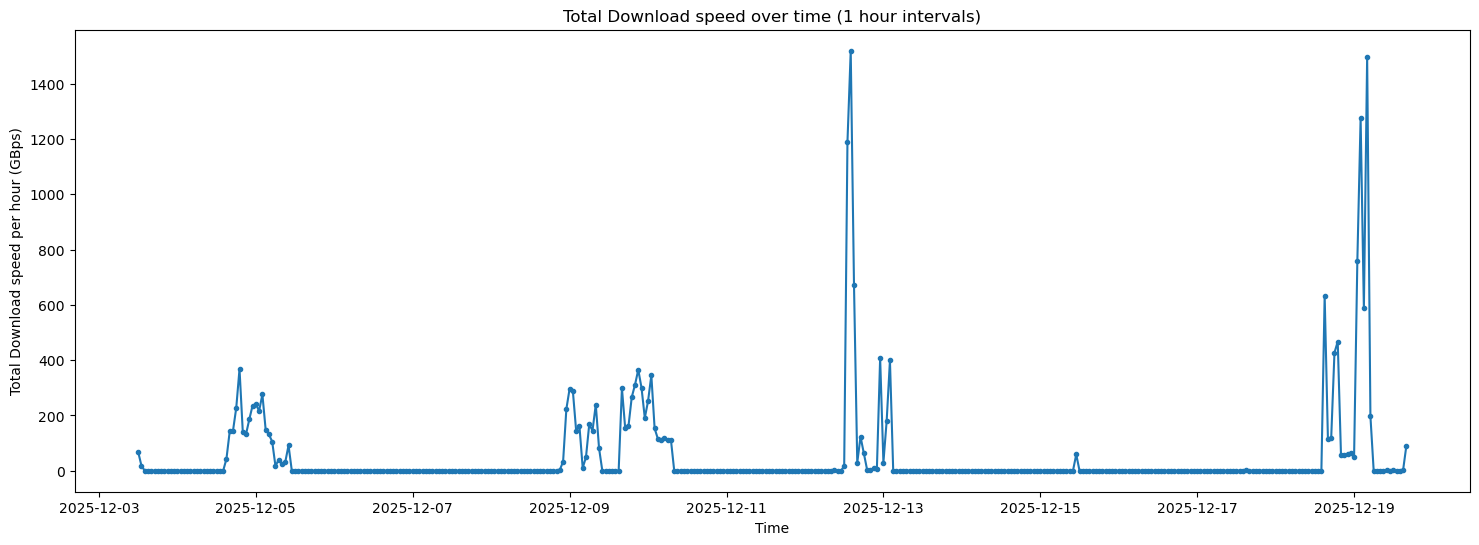

Average total download speed per hour: 208.64996969028496 GBps
Top 5 hours by total download speed (GBps):
2025-12-12 14:00:00: 1519.2212023114878 GBps
2025-12-19 04:00:00: 1496.4559739298056 GBps
2025-12-19 02:00:00: 1275.5630911104527 GBps
2025-12-12 13:00:00: 1188.5767835616796 GBps
2025-12-19 01:00:00: 758.1837137952458 GBps


In [16]:
# plot sum of download speed over one hour intervals
df['start_time_s'] = pd.to_datetime(df['start'], unit='s')
df2 = df.sort_values(by='start_time_s')
df2.set_index('start_time_s', inplace=True)
resampled = df2['rate_Bps'].resample('1h').sum()
# resampled = resampled[resampled > 0]
plt.figure(figsize=(18, 6))
plt.plot(resampled.index, resampled.values / (1024**3), marker='.', linestyle='-')
plt.xlabel('Time')
plt.ylabel('Total Download speed per hour (GBps)')
plt.title('Total Download speed over time (1 hour intervals)')
plt.savefig('../figs/total_download_speed_per_hour.png', bbox_inches='tight')
plt.show()

# print info about top 5 hours with highest total download speed
top_hours = resampled.sort_values(ascending=False).head(5)
print(f"Average total download speed per hour: {resampled[resampled > 0].mean() / (1024**3)} GBps")
print("Top 5 hours by total download speed (GBps):")
for time, speed in top_hours.items():
    print(f"{time}: {speed / (1024**3)} GBps")

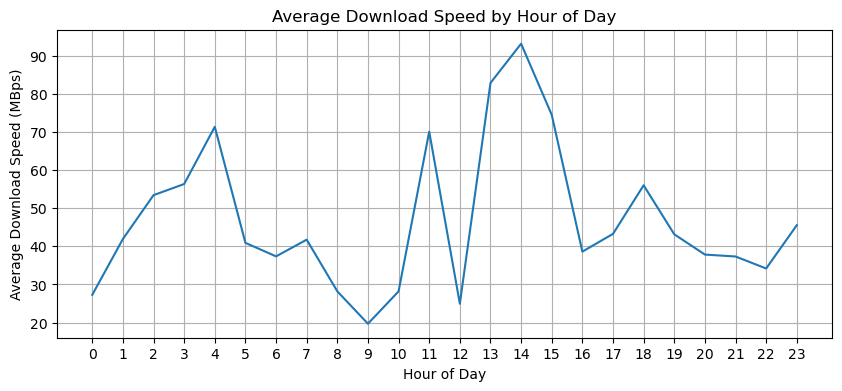

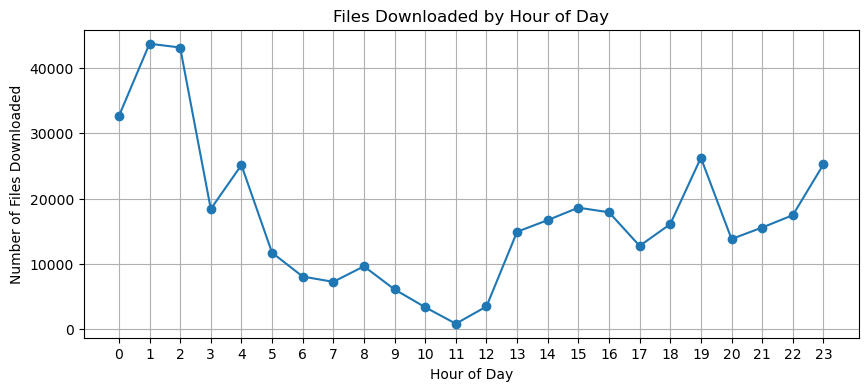

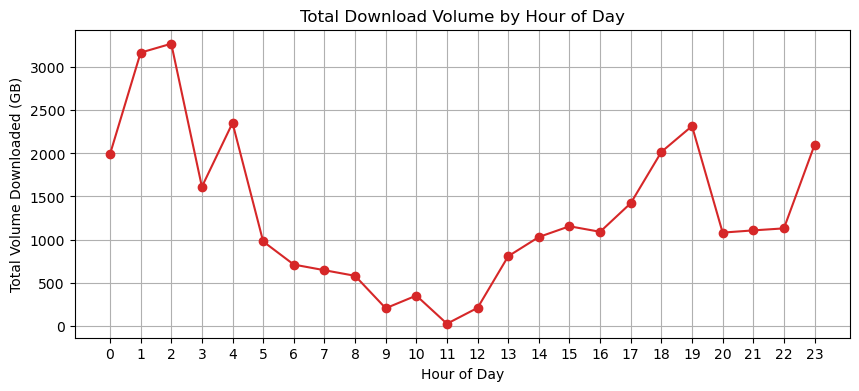

Top 3 hours by total downloaded volume (GB):
Hour 2.0: 3272.294 GB, files: 43078
Hour 1.0: 3169.026 GB, files: 43657
Hour 4.0: 2353.295 GB, files: 25114
Bottom 3 hours by total downloaded volume (GB):
Hour 11.0: 24.120 GB, files: 864
Hour 9.0: 203.591 GB, files: 6106
Hour 12.0: 208.148 GB, files: 3501


In [17]:
df['start_time'] = pd.to_datetime(df['start'], unit='s')
df['hour'] = df['start_time'].dt.hour
speed_by_hour = df.groupby('hour')['rate_Bps'].mean()
plt.figure(figsize=(10, 4))
plt.plot(speed_by_hour.index, speed_by_hour.values / (1024**2))
plt.xlabel('Hour of Day')
plt.ylabel('Average Download Speed (MBps)')
plt.title('Average Download Speed by Hour of Day')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

# New: weight of data per hour -> number of files and total volume
files_by_hour = df.groupby('hour').size()                     # number of files downloaded in each hour
total_volume_by_hour = df.groupby('hour')['bytes'].sum()      # total bytes downloaded in each hour

# Plot number of files per hour
plt.figure(figsize=(10, 4))
plt.plot(files_by_hour.index, files_by_hour.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Files Downloaded')
plt.title('Files Downloaded by Hour of Day')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

# Plot total volume per hour (GB)
plt.figure(figsize=(10, 4))
plt.plot(total_volume_by_hour.index, total_volume_by_hour.values / (1024**3), marker='o', color='C3')
plt.xlabel('Hour of Day')
plt.ylabel('Total Volume Downloaded (GB)')
plt.title('Total Download Volume by Hour of Day')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

# Short textual summary: top 3 hours by volume
top_hours = total_volume_by_hour.sort_values(ascending=False).head(3)
print("Top 3 hours by total downloaded volume (GB):")
for hour, bytes_ in top_hours.items():
    print(f"Hour {hour}: {bytes_ / (1024**3):.3f} GB, files: {files_by_hour.get(hour,0)}")

# bottom 3 hours by volume
bottom_hours = total_volume_by_hour[total_volume_by_hour > 0].sort_values().head(3)
print("Bottom 3 hours by total downloaded volume (GB):")
for hour, bytes_ in bottom_hours.items():
    print(f"Hour {hour}: {bytes_ / (1024**3):.3f} GB, files: {files_by_hour.get(hour,0)}")